# Avaliação histórica dos sinais de aumento incomum

## Objetivo

Avaliar retrospectivamente o comportamento da regra V1 de sinais de
aumento incomum, respeitando a ordem temporal dos dados.

A avaliação busca responder:

- quantos sinais a regra teria produzido no passado;
- em quais períodos esses sinais ocorreriam;
- quantos coincidem com eventos de referência definidos
  independentemente da regra;
- quantos sinais ocorreriam fora desses eventos;
- com que antecedência um sinal apareceria em relação ao início de um
  evento de referência.

A avaliação deve evitar vazamento de informação futura.

Um `SIGNAL` representa somente o atendimento aos critérios estatísticos
da regra V1. Ele não constitui confirmação de surto ou evento
epidemiológico.

## Separação temporal

Para evitar avaliar a regra nos mesmos períodos utilizados para sua
inspeção inicial, o histórico será dividido temporalmente em:

- desenvolvimento: 2019–2023;
- avaliação: 2024–2025;
- série corrente: 2026, não utilizada neste backtest.

A separação é temporal, e não aleatória, para preservar a ordem natural
da série e reduzir vazamento de informações futuras.

In [44]:
from pathlib import Path

import pandas as pd

In [45]:
project_root = Path.cwd().parent

assert (project_root / "data").exists(), (
    f"Diretório data não encontrado em {project_root}"
)

print(f"Raiz do projeto: {project_root}")

Raiz do projeto: /home/matheuspessoa/Sentinela


In [46]:
historical_weekly_path = (
    project_root
    / "data"
    / "processed"
    / "srag_mg_historical_weekly_2019_2026.csv"
)

assert historical_weekly_path.exists(), (
    f"Arquivo não encontrado: {historical_weekly_path}"
)

historical_weekly = pd.read_csv(
    historical_weekly_path,
    sep=";",
)

required_columns = {
    "epi_year",
    "epi_week",
    "record_count",
}

assert required_columns.issubset(
    historical_weekly.columns
), "Colunas obrigatórias ausentes."

assert not historical_weekly.duplicated(
    ["epi_year", "epi_week"]
).any()

print(f"Arquivo: {historical_weekly_path.name}")

print(
    "Anos disponíveis:",
    sorted(historical_weekly["epi_year"].unique()),
)

print(
    "Linhas semanais:",
    len(historical_weekly),
)

print("✓ Série histórica semanal carregada.")

Arquivo: srag_mg_historical_weekly_2019_2026.csv
Anos disponíveis: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Linhas semanais: 404
✓ Série histórica semanal carregada.


In [47]:
DEVELOPMENT_YEARS = list(range(2019, 2024))
EVALUATION_YEARS = [2024, 2025]

MIN_HISTORICAL_YEARS = 3
SIGNAL_FACTOR = 1.5

print("Desenvolvimento:", DEVELOPMENT_YEARS)
print("Avaliação:", EVALUATION_YEARS)

Desenvolvimento: [2019, 2020, 2021, 2022, 2023]
Avaliação: [2024, 2025]


In [48]:
def build_reference_before_year(
    weekly_data: pd.DataFrame,
    target_year: int,
) -> pd.DataFrame:

    past = weekly_data.loc[
        (weekly_data["epi_year"] < target_year)
        & (weekly_data["epi_week"].between(1, 52))
    ].copy()

    reference = (
        past
        .groupby("epi_week")["record_count"]
        .agg(
            historical_min="min",
            q25=lambda values: values.quantile(0.25),
            historical_median="median",
            q75=lambda values: values.quantile(0.75),
            historical_max="max",
            historical_years="count",
        )
        .reset_index()
    )

    reference["has_minimum_history"] = (
        reference["historical_years"]
        >= MIN_HISTORICAL_YEARS
    )

    return reference

In [49]:
reference_2024 = build_reference_before_year(
    historical_weekly,
    2024,
)

reference_2025 = build_reference_before_year(
    historical_weekly,
    2025,
)

assert reference_2024["historical_years"].eq(5).all()
assert reference_2025["historical_years"].eq(6).all()

print("✓ Referências temporais construídas sem informação futura.")
print(
    "2024:",
    reference_2024["historical_years"].min(),
    "anos anteriores",
)
print(
    "2025:",
    reference_2025["historical_years"].min(),
    "anos anteriores",
)

✓ Referências temporais construídas sem informação futura.
2024: 5 anos anteriores
2025: 6 anos anteriores


In [50]:
def evaluate_year(
    weekly_data: pd.DataFrame,
    target_year: int,
) -> pd.DataFrame:

    current = (
        weekly_data.loc[
            (
                (weekly_data["epi_year"] == target_year)
                & (weekly_data["epi_week"].between(1, 52))
            ),
            [
                "epi_year",
                "epi_week",
                "record_count",
            ],
        ]
        .copy()
    )

    reference = build_reference_before_year(
        weekly_data,
        target_year,
    )

    evaluation = current.merge(
        reference,
        on="epi_week",
        how="left",
        validate="one_to_one",
    )

    evaluation["median_threshold"] = (
        evaluation["historical_median"]
        * SIGNAL_FACTOR
    )

    evaluation["ratio_to_median"] = (
        evaluation["record_count"]
        / evaluation["historical_median"]
    )

    insufficient_data = (
        evaluation["historical_median"].isna()
        | evaluation["q75"].isna()
        | ~evaluation["has_minimum_history"].fillna(False)
    )

    signal = (
        ~insufficient_data
        & (evaluation["record_count"] > evaluation["q75"])
        & (
            evaluation["record_count"]
            >= evaluation["median_threshold"]
        )
    )

    evaluation["signal_status"] = "NO_SIGNAL"

    evaluation.loc[
        insufficient_data,
        "signal_status",
    ] = "INSUFFICIENT_DATA"

    evaluation.loc[
        signal,
        "signal_status",
    ] = "SIGNAL"

    return evaluation

In [51]:
backtest_frames = [
    evaluate_year(
        historical_weekly,
        year,
    )
    for year in EVALUATION_YEARS
]

backtest = (
    pd.concat(
        backtest_frames,
        ignore_index=True,
    )
    .sort_values(
        ["epi_year", "epi_week"]
    )
    .reset_index(drop=True)
)

assert set(backtest["epi_year"]) == {2024, 2025}

assert not backtest.duplicated(
    ["epi_year", "epi_week"]
).any()

print("✓ Backtest executado.")

display(backtest.head())

✓ Backtest executado.


,epi_year,epi_week,record_count,historical_min,q25,historical_median,q75,historical_max,historical_years,has_minimum_history,median_threshold,ratio_to_median,signal_status
0,2024,1,285,48,53.0,887.0,3696.0,4618,5,True,1330.5,0.321308,NO_SIGNAL
1,2024,2,276,43,48.0,667.0,4407.0,4559,5,True,1000.5,0.413793,NO_SIGNAL
2,2024,3,330,31,63.0,524.0,4053.0,4572,5,True,786.0,0.629771,NO_SIGNAL
3,2024,4,274,21,49.0,452.0,3779.0,3803,5,True,678.0,0.606195,NO_SIGNAL
4,2024,5,363,31,53.0,504.0,3317.0,4097,5,True,756.0,0.720238,NO_SIGNAL


In [52]:
signal_summary = (
    backtest
    .groupby(
        ["epi_year", "signal_status"]
    )
    .size()
    .unstack(fill_value=0)
)

display(signal_summary)

signal_status,NO_SIGNAL,SIGNAL
epi_year,,
2024,52,0
2025,46,6


In [53]:
historical_signals = (
    backtest.loc[
        backtest["signal_status"] == "SIGNAL",
        [
            "epi_year",
            "epi_week",
            "record_count",
            "historical_median",
            "q75",
            "median_threshold",
            "ratio_to_median",
            "historical_years",
        ],
    ]
    .copy()
)

display(historical_signals)

,epi_year,epi_week,record_count,historical_median,q75,median_threshold,ratio_to_median,historical_years
68,2025,17,1087,695.0,1063.50,1042.50,1.564029,6
69,2025,18,1586,744.5,1178.00,1116.75,2.130289,6
70,2025,19,1941,847.0,1285.25,1270.50,2.291617,6
71,2025,20,2201,986.0,1487.75,1479.00,2.232252,6
72,2025,21,2404,1029.5,1558.00,1544.25,2.335114,6
73,2025,22,2148,1145.0,1777.75,1717.50,1.875983,6


In [54]:
assert (
    historical_signals["record_count"]
    > historical_signals["q75"]
).all()

assert (
    historical_signals["record_count"]
    >= historical_signals["median_threshold"]
).all()

print("✓ Todos os sinais históricos satisfazem a regra V1.")

✓ Todos os sinais históricos satisfazem a regra V1.


In [55]:
assert backtest.loc[
    backtest["epi_year"] == 2024,
    "historical_years",
].eq(5).all()

assert backtest.loc[
    backtest["epi_year"] == 2025,
    "historical_years",
].eq(6).all()

print("✓ Backtest sem uso de anos futuros.")

✓ Backtest sem uso de anos futuros.


### Evidências externas — evento de referência 2025

O evento de referência de 2025 foi definido a partir de publicações
independentes da regra de sinais implementada pelo Sentinela.

As publicações foram utilizadas para identificar períodos em que fontes
externas documentaram crescimento ou atividade relevante de SRAG em
Minas Gerais ou Belo Horizonte.

#### Evidências

**11/04/2025 — InfoGripe: alerta para aumento de SRAG**

A publicação referente à SE 14 indicava Belo Horizonte entre as capitais
com sinal de crescimento de SRAG na tendência de longo prazo.

Fonte:
[InfoGripe — crescimento de SRAG em abril de 2025](https://agenciagov.ebc.com.br/noticias/202504/infogripe-alerta-para-aumento-de-srag-em-quase-todas-as-regioes-do-pais)

---

**Maio/2025 — InfoGripe: Influenza A segue em crescimento**

Publicação posterior manteve Belo Horizonte entre os locais com atividade
relevante/crescimento de SRAG, fornecendo evidência de continuidade do
período observado.

Fonte:
[InfoGripe — situação até a SE 20 de 2025](https://agenciagov.ebc.com.br/noticias/202505/infogripe-influenza-a-segue-em-crescimento-no-brasil)
---

**Junho/2025 — InfoGripe: situação até a SE 22**

A publicação referente ao período até a SE 22 incluiu Minas Gerais entre
as UFs com incidência em nível de alerta, risco ou alto risco acompanhada
de tendência de crescimento.

Fonte:
[InfoGripe — situação até a SE 22 de 2025](https://agenciagov.ebc.com.br/noticias/202506/infogripe-casos-de-influenza-a-e-vsr-seguem-em-crescimento-no-pais)

#### Uso no backtest

Essas evidências são externas e independentes da regra V1.

Os sinais produzidos pelo Sentinela não foram utilizados para escolher
as semanas do evento de referência.

A presença de um evento de referência indica um período documentado de
crescimento ou atividade relevante de SRAG e não deve ser interpretada
como confirmação de surto epidemiológico.

In [56]:
reference_events = pd.DataFrame(
    [
        {
            "event_id": "MG_2024_01",
            "region": "MG",
            "epi_year": 2024,
            "start_week": 15,
            "end_week": pd.NA,
            "start_definition": "first_external_documented_growth",
            "reference_source": "InfoGripe",
            "reference_description": (
                "Minas Gerais com sinal de crescimento de SRAG "
                "na tendência de longo prazo."
            ),
        },
        {
            "event_id": "MG_2025_01",
            "region": "MG",
            "epi_year": 2025,
            "start_week": 14,
            "end_week": pd.NA,
            "start_definition": "first_external_documented_growth",
            "reference_source": "InfoGripe",
            "reference_description": (
                "Minas Gerais com incidência em alerta, risco "
                "ou alto risco e crescimento de longo prazo."
            ),
        },
    ]
)

reference_events["start_week"] = (
    reference_events["start_week"].astype("Int64")
)

reference_events["end_week"] = (
    reference_events["end_week"].astype("Int64")
)

display(reference_events)

,event_id,region,epi_year,start_week,end_week,start_definition,reference_source,reference_description
0,MG_2024_01,MG,2024,15,<NA>,first_external_documented_growth,InfoGripe,Minas Gerais com sinal de crescimento de SRAG ...
1,MG_2025_01,MG,2025,14,<NA>,first_external_documented_growth,InfoGripe,"Minas Gerais com incidência em alerta, risco o..."


In [57]:
reference_evidence = pd.DataFrame(
    [
        {
            "event_id": "MG_2024_01",
            "epi_week": 13,
            "evidence_role": "pre_event",
            "geographic_scope": "MG",
            "finding": (
                "MG não listado entre as UFs com crescimento "
                "de longo prazo."
            ),
            "source": "InfoGripe / Agência Gov",
        },
        {
            "event_id": "MG_2024_01",
            "epi_week": 15,
            "evidence_role": "event_start",
            "geographic_scope": "MG",
            "finding": (
                "MG listado entre as UFs com crescimento "
                "de SRAG de longo prazo."
            ),
            "source": "InfoGripe / Agência Gov",
        },
        {
            "event_id": "MG_2025_01",
            "epi_week": 14,
            "evidence_role": "event_start",
            "geographic_scope": "MG",
            "finding": (
                "MG em alerta/risco/alto risco com crescimento "
                "de longo prazo."
            ),
            "source": "InfoGripe / Agência Gov",
        },
        {
            "event_id": "MG_2025_01",
            "epi_week": 25,
            "evidence_role": "event_continuation",
            "geographic_scope": "MG",
            "finding": (
                "MG ainda em alerta/risco/alto risco com "
                "crescimento de longo prazo."
            ),
            "source": "InfoGripe / Agência Gov",
        },
    ]
)

display(reference_evidence)

,event_id,epi_week,evidence_role,geographic_scope,finding,source
0,MG_2024_01,13,pre_event,MG,MG não listado entre as UFs com crescimento de...,InfoGripe / Agência Gov
1,MG_2024_01,15,event_start,MG,MG listado entre as UFs com crescimento de SRA...,InfoGripe / Agência Gov
2,MG_2025_01,14,event_start,MG,MG em alerta/risco/alto risco com crescimento ...,InfoGripe / Agência Gov
3,MG_2025_01,25,event_continuation,MG,MG ainda em alerta/risco/alto risco com cresci...,InfoGripe / Agência Gov


## Regra de avaliação dos eventos

Para cada evento de referência:

- considera-se `DETECTED` quando existe pelo menos um `SIGNAL` no mesmo
  ano epidemiológico a partir da semana de início documentada;
- o primeiro sinal posterior ou coincidente com o início é utilizado para
  calcular o tempo de detecção;
- `detection_delay_weeks = first_signal_week - start_week`;
- valor igual a zero representa detecção na mesma semana;
- valor positivo representa detecção após o início documentado;
- a ausência de sinal resulta em `NOT_DETECTED`.

Como o encerramento dos eventos de referência não está definido, sinais
fora dos eventos não serão classificados automaticamente como falsos
alertas nesta etapa.

Essa abordagem evita inferir o término de um evento a partir da própria
regra que está sendo avaliada.

In [58]:
event_evaluations = []

for _, event in reference_events.iterrows():
    year = int(event["epi_year"])
    start_week = int(event["start_week"])

    year_signals = backtest.loc[
        (backtest["epi_year"] == year)
        & (backtest["signal_status"] == "SIGNAL")
        & (backtest["epi_week"] >= start_week)
    ].copy()

    if year_signals.empty:
        first_signal_week = pd.NA
        detection_delay_weeks = pd.NA
        detection_status = "NOT_DETECTED"
    else:
        first_signal_week = int(
            year_signals["epi_week"].min()
        )

        detection_delay_weeks = (
            first_signal_week - start_week
        )

        detection_status = "DETECTED"

    event_evaluations.append(
        {
            "event_id": event["event_id"],
            "region": event["region"],
            "epi_year": year,
            "event_start_week": start_week,
            "first_signal_week": first_signal_week,
            "detection_delay_weeks": detection_delay_weeks,
            "detection_status": detection_status,
        }
    )

event_evaluation = pd.DataFrame(event_evaluations)

event_evaluation["first_signal_week"] = (
    event_evaluation["first_signal_week"].astype("Int64")
)

event_evaluation["detection_delay_weeks"] = (
    event_evaluation["detection_delay_weeks"].astype("Int64")
)

display(event_evaluation)

,event_id,region,epi_year,event_start_week,first_signal_week,detection_delay_weeks,detection_status
0,MG_2024_01,MG,2024,15,<NA>,<NA>,NOT_DETECTED
1,MG_2025_01,MG,2025,14,17,3,DETECTED


In [59]:
total_events = len(event_evaluations)

detected_events = (
    event_evaluation["detection_status"]
    .eq("DETECTED")
    .sum()
)

not_detected_events = (
    event_evaluation["detection_status"]
    .eq("NOT_DETECTED")
    .sum()
)

detection_rate = (
    detected_events / total_events
    if total_events > 0
    else float("nan")
)

print(f"Eventos de referência: {total_events}")
print(f"Eventos detectados: {detected_events}")
print(f"Eventos não detectados: {not_detected_events}")
print(f"Proporção detectada: {detection_rate:.1%}")

Eventos de referência: 2
Eventos detectados: 1
Eventos não detectados: 1
Proporção detectada: 50.0%


### Avaliação de falsos alertas

A avaliação de falsos alertas foi realizada somente em semanas para as
quais havia classificação externa explícita e independente da regra V1.

Foram avaliados 8 pontos externos:

- 5 classificados como `EVENT`;
- 3 classificados como `NO_EVENT`.

Nos 3 pontos negativos avaliáveis, a regra V1 não produziu sinais,
resultando em:

- 3 verdadeiros negativos;
- 0 falsos positivos;
- taxa observada de falsos positivos de 0%.

Esse resultado se aplica exclusivamente aos pontos externos avaliados.
O número de pontos negativos é pequeno e semanas sem evidência externa
suficiente não foram consideradas negativas.

Portanto, o resultado não deve ser interpretado como evidência de uma
taxa geral de falsos alertas de 0% ou de especificidade geral de 100%.

Na avaliação dos pontos positivos, houve 1 verdadeiro positivo e
4 falsos negativos entre 5 pontos classificados externamente como
`EVENT`.

As classificações representam concordância com a referência externa
adotada e não confirmação ou exclusão de surtos epidemiológicos.

In [60]:
assert len(event_evaluation) == len(reference_events)

assert set(
    event_evaluation["detection_status"]
) <= {"DETECTED", "NOT_DETECTED"}

detected = event_evaluation.loc[
    event_evaluation["detection_status"] == "DETECTED"
]

not_detected = event_evaluation.loc[
    event_evaluation["detection_status"] == "NOT_DETECTED"
]

assert detected["first_signal_week"].notna().all()
assert detected["detection_delay_weeks"].notna().all()

assert not_detected["first_signal_week"].isna().all()
assert not_detected["detection_delay_weeks"].isna().all()

assert (
    detected["detection_delay_weeks"]
    == (
        detected["first_signal_week"]
        - detected["event_start_week"]
    )
).all()

print("✓ Avaliação dos eventos validada.")
print(f"Eventos avaliados: {len(event_evaluation)}")
print(f"Detectados: {len(detected)}")
print(f"Não detectados: {len(not_detected)}")



✓ Avaliação dos eventos validada.
Eventos avaliados: 2
Detectados: 1
Não detectados: 1


In [61]:
evaluation_summary = pd.DataFrame(
    [
        {
            "reference_events": len(event_evaluation),
            "detected_events": len(detected),
            "not_detected_events": len(not_detected),
            "detection_proportion": (
                len(detected) / len(event_evaluation)
            ),
            "median_detection_delay_weeks": (
                detected["detection_delay_weeks"].median()
                if not detected.empty
                else pd.NA
            ),
            "false_alert_rate": pd.NA,
        }
    ]
)

display(evaluation_summary)

,reference_events,detected_events,not_detected_events,detection_proportion,median_detection_delay_weeks,false_alert_rate
0,2,1,1,0.5,3.0,<NA>


In [62]:
output_dir = project_root / "data" / "processed"

events_path = (
    output_dir
    / "srag_mg_reference_events_2024_2025.csv"
)

event_evaluation_path = (
    output_dir
    / "srag_mg_historical_alert_evaluation.csv"
)

evaluation_summary_path = (
    output_dir
    / "srag_mg_historical_alert_evaluation_summary.csv"
)

reference_events.to_csv(
    events_path,
    sep=";",
    index=False,
    encoding="utf-8",
    na_rep="",
)

event_evaluation.to_csv(
    event_evaluation_path,
    sep=";",
    index=False,
    encoding="utf-8",
    na_rep="",
)

evaluation_summary.to_csv(
    evaluation_summary_path,
    sep=";",
    index=False,
    encoding="utf-8",
    na_rep="",
)

print("✓ Resultados exportados.")
print(events_path)
print(event_evaluation_path)
print(evaluation_summary_path)

✓ Resultados exportados.
/home/matheuspessoa/Sentinela/data/processed/srag_mg_reference_events_2024_2025.csv
/home/matheuspessoa/Sentinela/data/processed/srag_mg_historical_alert_evaluation.csv
/home/matheuspessoa/Sentinela/data/processed/srag_mg_historical_alert_evaluation_summary.csv


## Resultado da avaliação histórica

A regra V1 foi avaliada retrospectivamente nos anos de 2024 e 2025,
utilizando somente anos anteriores para construir a referência de cada
ano avaliado.

Foram definidos dois eventos externos de referência:

- `MG_2024_01`: início documentado na SE 15 de 2024;
- `MG_2025_01`: início documentado na SE 14 de 2025.

### Resultados

Em 2024, a regra V1 não produziu sinais durante o ano. O evento externo
de referência iniciado na SE 15 foi, portanto, classificado como
`NOT_DETECTED`.

Em 2025, a regra produziu seu primeiro sinal na SE 17. Como o evento
externo de referência possui início documentado na SE 14, o evento foi
classificado como `DETECTED`, com atraso de 3 semanas em relação ao
início documentado.

Dos dois eventos externos avaliados, um foi detectado e um não foi
detectado, correspondendo a uma proporção observada de detecção de 50%.

Essa proporção é descritiva deste conjunto de avaliação, composto por
apenas dois eventos, e não deve ser interpretada como uma estimativa
robusta de sensibilidade da regra.

### Falsos alertas

A taxa de falsos alertas não foi estimada.

Embora os eventos possuam início documentado por fontes externas, seus
encerramentos não foram estabelecidos de forma independente. Dessa forma,
não existem janelas negativas suficientemente definidas para classificar
com segurança um sinal como falso alerta.

### Antecedência e atraso

Nenhum evento avaliado apresentou detecção anterior ao início externo
documentado.

O evento de 2025 apresentou primeiro sinal 3 semanas após o início de
referência, caracterizando atraso de detecção, e não antecedência.

### Limitações

A avaliação contém somente dois eventos externos de referência e dois
anos de avaliação.

Os eventos externos representam períodos documentados de crescimento ou
atividade relevante de SRAG e não constituem necessariamente confirmação
de surto epidemiológico.

A ausência de um sinal não demonstra ausência de atividade epidemiológica,
assim como a presença de um `SIGNAL` não confirma um surto.

A regra V1 não deve ser reajustada utilizando os resultados de 2024 e
2025 sem uma nova separação entre desenvolvimento e avaliação, pois isso
introduziria informação do conjunto de avaliação no desenvolvimento do
método.

## Classificação externa das semanas

A avaliação de falsos alertas utiliza somente semanas para as quais existe
evidência externa suficientemente clara.

Estados possíveis:

- `EVENT`: evidência externa explícita de crescimento de SRAG em Minas Gerais;
- `NO_EVENT`: evidência externa explícita de ausência de crescimento, queda
  ou estabilidade segundo o critério adotado;
- `UNKNOWN`: evidência insuficiente ou ambígua.

Semanas `UNKNOWN` são excluídas do cálculo de falsos alertas.

A ausência de publicação ou de menção a Minas Gerais não é interpretada
como `NO_EVENT`.

In [63]:
reference_timeline = pd.DataFrame(
    [
        {
            "epi_year": 2024,
            "epi_week": 13,
            "external_status": "NO_EVENT",
            "finding": (
                "MG não estava entre as UFs com crescimento de SRAG "
                "na tendência de longo prazo; cenário nacional em queda."
            ),
            "source": "InfoGripe / Agência Gov",
            "url": (
                "https://agenciagov.ebc.com.br/noticias/202404/"
                "infogripe-aponta-queda-de-srag-e-aumento-de-casos-"
                "de-vsr-e-gripe"
            ),
        },
        {
            "epi_year": 2024,
            "epi_week": 15,
            "external_status": "EVENT",
            "finding": (
                "MG listado entre as UFs com crescimento de SRAG "
                "na tendência de longo prazo."
            ),
            "source": "InfoGripe / Agência Gov",
            "url": (
                "https://agenciagov.ebc.com.br/noticias/202404/"
                "infogripe-internacoes-por-vsr-e-influenza-a-"
                "seguem-em-alta"
            ),
        },
        {
            "epi_year": 2025,
            "epi_week": 14,
            "external_status": "EVENT",
            "finding": (
                "MG em alerta/risco/alto risco com crescimento "
                "na tendência de longo prazo."
            ),
            "source": "InfoGripe / Agência Gov",
            "url": (
                "https://agenciagov.ebc.com.br/noticias/202504/"
                "infogripe-alerta-para-aumento-de-srag-em-quase-"
                "todas-as-regioes-do-pais"
            ),
        },
        {
            "epi_year": 2025,
            "epi_week": 20,
            "external_status": "EVENT",
            "finding": (
                "Continuidade externa documentada do período "
                "de crescimento de SRAG."
            ),
            "source": "InfoGripe / Agência Gov",
            "url": (
                "https://agenciagov.ebc.com.br/login?came_from=/noticias/202505/"
                "infogripe-influenza-a-segue-em-crescimento-no-brasil"
            ),
        },
        {
            "epi_year": 2025,
            "epi_week": 24,
            "external_status": "EVENT",
            "finding": (
                "MG ainda listado entre as UFs com crescimento "
                "na tendência de longo prazo."
            ),
            "source": "InfoGripe / Agência Gov",
            "url": (
                "https://agenciagov.ebc.com.br/noticias/202506/"
                "infogripe-casos-de-srag-seguem-em-crescimento-"
                "em-parte-do-pais"
            ),
        },
        {
            "epi_year": 2025,
            "epi_week": 31,
            "external_status": "NO_EVENT",
            "finding": (
                "MG com incidência elevada, porém sem sinal de "
                "crescimento na tendência de longo prazo."
            ),
            "source": "InfoGripe / Agência Gov",
            "url": (
                "https://agenciagov.ebc.com.br/noticias/202508/"
                "infogripe-casos-de-vsr-em-criancas-se-mantem-"
                "em-niveis-elevados"
            ),
        },
        {
            "epi_year": 2025,
            "epi_week": 33,
            "external_status": "NO_EVENT",
            "finding": (
                "Nenhuma UF apresentava crescimento na tendência "
                "de longo prazo; MG permanecia elevado, mas sem crescimento."
            ),
            "source": "InfoGripe / Agência Gov",
            "url": (
                "https://agenciagov.ebc.com.br/noticias/202508/"
                "infogripe-aponta-manutencao-de-queda-do-numero-"
                "de-casos-de-srag-em-quase-todo-o-pais"
            ),
        },
        {
            "epi_year": 2025,
            "epi_week": 26,
            "external_status": "EVENT",
            "finding": (
                "MG ainda apresentava crescimento de SRAG associado "
                "à influenza A em jovens, adultos e idosos, apesar de "
                "queda/interrupção do VSR em crianças pequenas."
            ),
            "source": "InfoGripe / Agência Gov",
            "url": (
                "https://agenciagov.ebc.com.br/noticias/202507/"
                "boletim-infogripe-mostra-que-a-influenza-a-e-"
                "responsavel-por-74-dos-obitos-por-srag"
            ),
        }
    ]
)

display(reference_timeline)

,epi_year,epi_week,external_status,finding,source,url
0,2024,13,NO_EVENT,MG não estava entre as UFs com crescimento de ...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202404/...
1,2024,15,EVENT,MG listado entre as UFs com crescimento de SRA...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202404/...
2,2025,14,EVENT,MG em alerta/risco/alto risco com crescimento ...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202504/...
3,2025,20,EVENT,Continuidade externa documentada do período de...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/login?came_from=...
4,2025,24,EVENT,MG ainda listado entre as UFs com crescimento ...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202506/...
5,2025,31,NO_EVENT,"MG com incidência elevada, porém sem sinal de ...",InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202508/...
6,2025,33,NO_EVENT,Nenhuma UF apresentava crescimento na tendênci...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202508/...
7,2025,26,EVENT,MG ainda apresentava crescimento de SRAG assoc...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202507/...


In [64]:
reference_timeline.loc[
    (reference_timeline["epi_year"] == 2025)
    & (reference_timeline["epi_week"] == 20),
    "url",
] = (
    "https://agenciagov.ebc.com.br/noticias/202505/"
    "infogripe-influenza-a-segue-em-crescimento-no-brasil"
)

reference_timeline = (
    reference_timeline
    .sort_values(["epi_year", "epi_week"])
    .reset_index(drop=True)
)

assert reference_timeline["url"].notna().all()

display(reference_timeline)

,epi_year,epi_week,external_status,finding,source,url
0,2024,13,NO_EVENT,MG não estava entre as UFs com crescimento de ...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202404/...
1,2024,15,EVENT,MG listado entre as UFs com crescimento de SRA...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202404/...
2,2025,14,EVENT,MG em alerta/risco/alto risco com crescimento ...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202504/...
3,2025,20,EVENT,Continuidade externa documentada do período de...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202505/...
4,2025,24,EVENT,MG ainda listado entre as UFs com crescimento ...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202506/...
5,2025,26,EVENT,MG ainda apresentava crescimento de SRAG assoc...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202507/...
6,2025,31,NO_EVENT,"MG com incidência elevada, porém sem sinal de ...",InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202508/...
7,2025,33,NO_EVENT,Nenhuma UF apresentava crescimento na tendênci...,InfoGripe / Agência Gov,https://agenciagov.ebc.com.br/noticias/202508/...


In [65]:
external_evaluation = reference_timeline.merge(
    backtest[
        [
            "epi_year",
            "epi_week",
            "record_count",
            "signal_status",
        ]
    ],
    on=["epi_year", "epi_week"],
    how="left",
    validate="one_to_one",
)

assert external_evaluation["signal_status"].notna().all()

display(
    external_evaluation[
        [
            "epi_year",
            "epi_week",
            "external_status",
            "record_count",
            "signal_status",
        ]
    ]
)

,epi_year,epi_week,external_status,record_count,signal_status
0,2024,13,NO_EVENT,538,NO_SIGNAL
1,2024,15,EVENT,662,NO_SIGNAL
2,2025,14,EVENT,774,NO_SIGNAL
3,2025,20,EVENT,2201,SIGNAL
4,2025,24,EVENT,1812,NO_SIGNAL
5,2025,26,EVENT,1358,NO_SIGNAL
6,2025,31,NO_EVENT,717,NO_SIGNAL
7,2025,33,NO_EVENT,656,NO_SIGNAL


### Classificação dos pontos externos

As classificações `TRUE_POSITIVE`, `FALSE_POSITIVE`,
`TRUE_NEGATIVE` e `FALSE_NEGATIVE` representam concordância ou
discordância entre a regra V1 e os pontos de referência externos
selecionados.

Elas não representam confirmação ou exclusão de surtos.

Somente semanas com classificação externa explícita `EVENT` ou
`NO_EVENT` são avaliadas. Semanas sem evidência externa suficiente
permanecem fora desta análise.

In [66]:
def classify_evaluation(row):
    external = row["external_status"]
    signal = row["signal_status"]

    if external == "EVENT" and signal == "SIGNAL":
        return "TRUE_POSITIVE"

    if external == "EVENT" and signal == "NO_SIGNAL":
        return "FALSE_NEGATIVE"

    if external == "NO_EVENT" and signal == "SIGNAL":
        return "FALSE_POSITIVE"

    if external == "NO_EVENT" and signal == "NO_SIGNAL":
        return "TRUE_NEGATIVE"

    return "NOT_EVALUABLE"


external_evaluation["evaluation_result"] = (
    external_evaluation.apply(
        classify_evaluation,
        axis=1,
    )
)

display(
    external_evaluation[
        [
            "epi_year",
            "epi_week",
            "external_status",
            "signal_status",
            "evaluation_result",
        ]
    ]
)

,epi_year,epi_week,external_status,signal_status,evaluation_result
0,2024,13,NO_EVENT,NO_SIGNAL,TRUE_NEGATIVE
1,2024,15,EVENT,NO_SIGNAL,FALSE_NEGATIVE
2,2025,14,EVENT,NO_SIGNAL,FALSE_NEGATIVE
3,2025,20,EVENT,SIGNAL,TRUE_POSITIVE
4,2025,24,EVENT,NO_SIGNAL,FALSE_NEGATIVE
5,2025,26,EVENT,NO_SIGNAL,FALSE_NEGATIVE
6,2025,31,NO_EVENT,NO_SIGNAL,TRUE_NEGATIVE
7,2025,33,NO_EVENT,NO_SIGNAL,TRUE_NEGATIVE


In [67]:
evaluation_counts = (
    external_evaluation["evaluation_result"]
    .value_counts()
    .reindex(
        [
            "TRUE_POSITIVE",
            "FALSE_POSITIVE",
            "TRUE_NEGATIVE",
            "FALSE_NEGATIVE",
        ],
        fill_value=0,
    )
)

tp = int(evaluation_counts["TRUE_POSITIVE"])
fp = int(evaluation_counts["FALSE_POSITIVE"])
tn = int(evaluation_counts["TRUE_NEGATIVE"])
fn = int(evaluation_counts["FALSE_NEGATIVE"])

positive_points = tp + fn
negative_points = tn + fp

sensitivity = (
    tp / positive_points
    if positive_points > 0
    else float("nan")
)

false_positive_rate = (
    fp / negative_points
    if negative_points > 0
    else float("nan")
)

specificity = (
    tn / negative_points
    if negative_points > 0
    else float("nan")
)

evaluation_metrics = pd.DataFrame(
    [
        {
            "evaluated_points": tp + fp + tn + fn,
            "positive_reference_points": positive_points,
            "negative_reference_points": negative_points,
            "true_positive": tp,
            "false_positive": fp,
            "true_negative": tn,
            "false_negative": fn,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "false_positive_rate": false_positive_rate,
        }
    ]
)

display(evaluation_metrics)

,evaluated_points,positive_reference_points,negative_reference_points,true_positive,false_positive,true_negative,false_negative,sensitivity,specificity,false_positive_rate
0,8,5,3,1,0,3,4,0.2,1.0,0.0


In [68]:
assert tp == 1
assert fp == 0
assert tn == 3
assert fn == 4

assert tp + fn == 5
assert tn + fp == 3

assert len(external_evaluation) == 8

assert external_evaluation[
    "evaluation_result"
].isin(
    [
        "TRUE_POSITIVE",
        "FALSE_POSITIVE",
        "TRUE_NEGATIVE",
        "FALSE_NEGATIVE",
    ]
).all()

print("✓ Avaliação externa validada.")
print(f"Pontos avaliados: {len(external_evaluation)}")
print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"TN: {tn}")
print(f"FN: {fn}")
print(f"Sensibilidade observada: {sensitivity:.1%}")
print(f"Especificidade observada: {specificity:.1%}")
print(
    "Taxa observada de falsos alertas: "
    f"{false_positive_rate:.1%}"
)

✓ Avaliação externa validada.
Pontos avaliados: 8
TP: 1
FP: 0
TN: 3
FN: 4
Sensibilidade observada: 20.0%
Especificidade observada: 100.0%
Taxa observada de falsos alertas: 0.0%


In [69]:
output_dir = project_root / "data" / "processed"

exports = {
    "reference_events": (
        reference_events,
        output_dir / "srag_mg_reference_events_2024_2025.csv",
    ),
    "reference_timeline": (
        reference_timeline,
        output_dir / "srag_mg_reference_timeline_2024_2025.csv",
    ),
    "event_evaluation": (
        event_evaluation,
        output_dir / "srag_mg_event_evaluation_2024_2025.csv",
    ),
    "external_evaluation": (
        external_evaluation,
        output_dir / "srag_mg_external_evaluation_2024_2025.csv",
    ),
    "evaluation_metrics": (
        evaluation_metrics,
        output_dir / "srag_mg_alert_evaluation_metrics.csv",
    ),
}

for name, (df, path) in exports.items():
    df.to_csv(
        path,
        sep=";",
        index=False,
        encoding="utf-8",
        na_rep="",
    )

    print(f"✓ {name}: {path}")

✓ reference_events: /home/matheuspessoa/Sentinela/data/processed/srag_mg_reference_events_2024_2025.csv
✓ reference_timeline: /home/matheuspessoa/Sentinela/data/processed/srag_mg_reference_timeline_2024_2025.csv
✓ event_evaluation: /home/matheuspessoa/Sentinela/data/processed/srag_mg_event_evaluation_2024_2025.csv
✓ external_evaluation: /home/matheuspessoa/Sentinela/data/processed/srag_mg_external_evaluation_2024_2025.csv
✓ evaluation_metrics: /home/matheuspessoa/Sentinela/data/processed/srag_mg_alert_evaluation_metrics.csv


In [70]:
assert len(reference_events) == 2
assert len(event_evaluation) == 2

assert (
    event_evaluation["detection_status"]
    .value_counts()
    .to_dict()
    == {
        "NOT_DETECTED": 1,
        "DETECTED": 1,
    }
)

# Pontos externos
assert len(external_evaluation) == 8

expected_counts = {
    "TRUE_POSITIVE": 1,
    "FALSE_POSITIVE": 0,
    "TRUE_NEGATIVE": 3,
    "FALSE_NEGATIVE": 4,
}

actual_counts = (
    external_evaluation["evaluation_result"]
    .value_counts()
    .reindex(expected_counts, fill_value=0)
    .to_dict()
)

assert actual_counts == expected_counts

# 2025
event_2025 = event_evaluation.loc[
    event_evaluation["event_id"] == "MG_2025_01"
].iloc[0]

assert event_2025["first_signal_week"] == 17
assert event_2025["detection_delay_weeks"] == 3

print("=" * 55)
print("RESUMO DA AVALIAÇÃO HISTÓRICA")
print("=" * 55)

print("\nAvaliação por evento:")
print("Eventos externos: 2")
print("Detectados: 1")
print("Não detectados: 1")
print("2025: primeiro sinal 3 semanas após o início documentado")

print("\nAvaliação por pontos externos:")
print("Pontos avaliados: 8")
print("TP: 1")
print("FP: 0")
print("TN: 3")
print("FN: 4")

print("\nLimitações:")
print("- Apenas dois eventos independentes avaliados")
print("- Apenas três pontos externos negativos")
print("- Semanas sem evidência externa foram excluídas")
print("- SIGNAL não representa confirmação de surto")

print("\n✓ Avaliação histórica reproduzida e validada.")
print("=" * 55)

RESUMO DA AVALIAÇÃO HISTÓRICA

Avaliação por evento:
Eventos externos: 2
Detectados: 1
Não detectados: 1
2025: primeiro sinal 3 semanas após o início documentado

Avaliação por pontos externos:
Pontos avaliados: 8
TP: 1
FP: 0
TN: 3
FN: 4

Limitações:
- Apenas dois eventos independentes avaliados
- Apenas três pontos externos negativos
- Semanas sem evidência externa foram excluídas
- SIGNAL não representa confirmação de surto

✓ Avaliação histórica reproduzida e validada.


## Resultado

A regra V1 foi avaliada retrospectivamente utilizando referências
históricas construídas somente com dados anteriores ao ano avaliado.

### Avaliação por evento

- Eventos externos avaliados: 2
- Detectados: 1
- Não detectados: 1
- Evento de 2025: primeiro sinal 3 semanas após o início documentado

### Avaliação por pontos externos

- Pontos avaliados: 8
- Verdadeiros positivos (TP): 1
- Falsos positivos (FP): 0
- Verdadeiros negativos (TN): 3
- Falsos negativos (FN): 4

### Limitações

- Apenas dois eventos independentes foram avaliados.
- Apenas três pontos externos negativos estavam disponíveis.
- Semanas sem evidência externa suficiente foram excluídas.
- Os resultados por ponto são complementares à avaliação por evento.
- `SIGNAL` representa um sinal estatístico e não confirmação de surto.

## Processamento e validação — MG 2025

A partir desta seção, os cálculos são referentes ao conjunto de dados de **SRAG em residentes de Minas Gerais no ano de 2025**.

Para evitar vazamento de informação, a referência histórica utilizada para 2025 considera apenas os anos anteriores disponíveis:

- **Período de referência:** 2019–2024
- **Ano avaliado:** 2025
- **Unidade de análise:** semana epidemiológica
- **Região:** Minas Gerais (MG)

Os objetivos desta etapa são:

- construir a série semanal de 2025;
- gerar a cobertura das 52 semanas epidemiológicas;
- construir a referência histórica usando somente 2019–2024;
- aplicar a regra de sinal de aumento incomum;
- exportar os artefatos necessários para consumo pela API e pelo dashboard;
- validar os resultados antes de disponibilizar 2025 no painel.

### Artefatos esperados

- `data/processed/srag_2025_mg_weekly.csv`
- `data/processed/srag_2025_mg_weekly_coverage.csv`
- `data/processed/srag_2025_mg_signal_evaluation.csv`
- `data/processed/srag_mg_historical_reference_2019_2024.csv`

> **Importante:** os resultados desta seção são independentes da análise de 2026. O ano de 2025 não é utilizado na construção da própria referência histórica.

In [71]:
reference_2025 = build_reference_before_year(
    historical_weekly,
    2025,
)

reference_2025.head()

,epi_week,historical_min,q25,historical_median,q75,historical_max,historical_years,has_minimum_history
0,1,48,111.00,586.0,2993.75,4618,6,True
1,2,43,105.00,471.5,3472.00,4559,6,True
2,3,31,129.75,427.0,3170.75,4572,6,True
3,4,21,105.25,363.0,2947.25,3803,6,True
4,5,31,130.50,433.5,2613.75,4097,6,True


In [72]:
assert reference_2025["historical_years"].min() == 6

print(
    reference_2025[
        [
            "epi_week",
            "historical_median",
            "q75",
            "historical_years",
        ]
    ].head()
)

   epi_week  historical_median      q75  historical_years
0         1              586.0  2993.75                 6
1         2              471.5  3472.00                 6
2         3              427.0  3170.75                 6
3         4              363.0  2947.25                 6
4         5              433.5  2613.75                 6


In [73]:
summary = (
    historical_weekly
    .groupby("epi_year", as_index=False)["record_count"]
    .sum()
)

display(summary)

,epi_year,record_count
0,2019,4035
1,2020,113781
2,2021,209248
3,2022,69332
4,2023,25613
5,2024,27271
6,2025,45655
7,2026,29087


In [74]:
display(
    historical_weekly.loc[
        historical_weekly["epi_year"] == 2025
    ].sort_values("epi_week")
)

,epi_year,epi_week,record_count
313,2025,1,397
314,2025,2,422
315,2025,3,413
316,2025,4,412
317,2025,5,359
318,2025,6,402
319,2025,7,469
320,2025,8,484
321,2025,9,486
322,2025,10,487


In [75]:
summary = (
    historical_weekly
    .groupby("epi_year")
    .agg(
        weeks=("epi_week", "nunique"),
        min_week=("epi_week", "min"),
        max_week=("epi_week", "max"),
        total=("record_count", "sum"),
    )
)

display(summary)

,weeks,min_week,max_week,total
epi_year,,,,
2019,52,1,52,4035
2020,53,1,53,113781
2021,52,1,52,209248
2022,52,1,52,69332
2023,52,1,52,25613
2024,52,1,52,27271
2025,53,1,53,45655
2026,38,1,38,29087


In [76]:
display(
    historical_weekly.loc[
        historical_weekly["epi_year"].isin([2024, 2025, 2026])
    ]
    .groupby("epi_year")
    .agg(
        weeks=("epi_week", "nunique"),
        total=("record_count", "sum"),
    )
)

,weeks,total
epi_year,,
2024,52,27271
2025,53,45655
2026,38,29087


In [77]:
weekly_2025 = (
    historical_weekly.loc[
        historical_weekly["epi_year"] == 2025,
        [
            "epi_week",
            "record_count",
        ]
    ]
    .sort_values("epi_week")
    .reset_index(drop=True)
)

assert len(weekly_2025) == 53
assert weekly_2025["epi_week"].is_unique
assert weekly_2025["epi_week"].min() == 1
assert weekly_2025["epi_week"].max() == 53
assert weekly_2025["record_count"].sum() == 45_655

print("Semanas:", len(weekly_2025))
print(
    "Registros:",
    int(weekly_2025["record_count"].sum()),
)

display(weekly_2025.head())
display(weekly_2025.tail())

Semanas: 53
Registros: 45655


,epi_week,record_count
0,1,397
1,2,422
2,3,413
3,4,412
4,5,359


,epi_week,record_count
48,49,610
49,50,555
50,51,550
51,52,480
52,53,482


In [78]:
from datetime import date, timedelta

coverage_2025 = weekly_2025.copy()

coverage_2025["epi_year"] = 2025

first_week_start = date(2024, 12, 29)

coverage_2025["week_start"] = coverage_2025[
    "epi_week"
].apply(
    lambda week: (
        first_week_start
        + timedelta(weeks=week - 1)
    ).isoformat()
)

coverage_2025["week_end"] = coverage_2025[
    "epi_week"
].apply(
    lambda week: (
        first_week_start
        + timedelta(
            weeks=week - 1,
            days=6,
        )
    ).isoformat()
)

coverage_2025["cumulative_record_count"] = (
    coverage_2025["record_count"].cumsum()
)

coverage_2025["calendar_status"] = "encerrada"
coverage_2025["data_status"] = "observado"

coverage_2025 = coverage_2025[
    [
        "epi_week",
        "epi_year",
        "week_start",
        "week_end",
        "record_count",
        "cumulative_record_count",
        "calendar_status",
        "data_status",
    ]
]


In [79]:
assert len(coverage_2025) == 53

assert coverage_2025["epi_week"].is_unique

assert coverage_2025["epi_week"].min() == 1

assert coverage_2025["epi_week"].max() == 53

assert (
    coverage_2025["record_count"].sum()
    == 45_655
)

assert coverage_2025[
    "calendar_status"
].eq("encerrada").all()

assert coverage_2025[
    "data_status"
].eq("observado").all()

print(
    "Semanas:",
    len(coverage_2025),
)

print(
    "Registros:",
    int(
        coverage_2025[
            "record_count"
        ].sum()
    ),
)

display(coverage_2025.head())
display(coverage_2025.tail())


Semanas: 53
Registros: 45655


,epi_week,epi_year,week_start,week_end,record_count,cumulative_record_count,calendar_status,data_status
0,1,2025,2024-12-29,2025-01-04,397,397,encerrada,observado
1,2,2025,2025-01-05,2025-01-11,422,819,encerrada,observado
2,3,2025,2025-01-12,2025-01-18,413,1232,encerrada,observado
3,4,2025,2025-01-19,2025-01-25,412,1644,encerrada,observado
4,5,2025,2025-01-26,2025-02-01,359,2003,encerrada,observado


,epi_week,epi_year,week_start,week_end,record_count,cumulative_record_count,calendar_status,data_status
48,49,2025,2025-11-30,2025-12-06,610,43588,encerrada,observado
49,50,2025,2025-12-07,2025-12-13,555,44143,encerrada,observado
50,51,2025,2025-12-14,2025-12-20,550,44693,encerrada,observado
51,52,2025,2025-12-21,2025-12-27,480,45173,encerrada,observado
52,53,2025,2025-12-28,2026-01-03,482,45655,encerrada,observado


In [84]:
signal_evaluation_2025 = coverage_2025.merge(
    reference_2025[
        [
            "epi_week",
            "historical_median",
            "q25",
            "q75",
            "historical_years",
            "has_minimum_history",
        ]
    ],
    on="epi_week",
    how="left",
    validate="one_to_one",
)

signal_evaluation_2025["region"] = "MG"

display(signal_evaluation_2025.head())
display(signal_evaluation_2025.tail())

,epi_week,epi_year,week_start,week_end,record_count,cumulative_record_count,calendar_status,data_status,historical_median,q25,q75,historical_years,has_minimum_history,region
0,1,2025,2024-12-29,2025-01-04,397,397,encerrada,observado,586.0,111.00,2993.75,6.0,True,MG
1,2,2025,2025-01-05,2025-01-11,422,819,encerrada,observado,471.5,105.00,3472.00,6.0,True,MG
2,3,2025,2025-01-12,2025-01-18,413,1232,encerrada,observado,427.0,129.75,3170.75,6.0,True,MG
3,4,2025,2025-01-19,2025-01-25,412,1644,encerrada,observado,363.0,105.25,2947.25,6.0,True,MG
4,5,2025,2025-01-26,2025-02-01,359,2003,encerrada,observado,433.5,130.50,2613.75,6.0,True,MG


,epi_week,epi_year,week_start,week_end,record_count,cumulative_record_count,calendar_status,data_status,historical_median,q25,q75,historical_years,has_minimum_history,region
48,49,2025,2025-11-30,2025-12-06,610,43588,encerrada,observado,915.0,370.50,1440.00,6.0,True,MG
49,50,2025,2025-12-07,2025-12-13,555,44143,encerrada,observado,875.5,343.50,1430.75,6.0,True,MG
50,51,2025,2025-12-14,2025-12-20,550,44693,encerrada,observado,792.0,338.25,1859.25,6.0,True,MG
51,52,2025,2025-12-21,2025-12-27,480,45173,encerrada,observado,718.0,286.00,2359.00,6.0,True,MG
52,53,2025,2025-12-28,2026-01-03,482,45655,encerrada,observado,NaN,NaN,NaN,NaN,NaN,MG


In [80]:
print(reference_2025.columns.tolist())
display(reference_2025.head())

['epi_week', 'historical_min', 'q25', 'historical_median', 'q75', 'historical_max', 'historical_years', 'has_minimum_history']


,epi_week,historical_min,q25,historical_median,q75,historical_max,historical_years,has_minimum_history
0,1,48,111.00,586.0,2993.75,4618,6,True
1,2,43,105.00,471.5,3472.00,4559,6,True
2,3,31,129.75,427.0,3170.75,4572,6,True
3,4,21,105.25,363.0,2947.25,3803,6,True
4,5,31,130.50,433.5,2613.75,4097,6,True


In [83]:
print(reference_2025.columns.tolist())

['epi_week', 'historical_min', 'q25', 'historical_median', 'q75', 'historical_max', 'historical_years', 'has_minimum_history']


In [85]:
SIGNAL_FACTOR = 1.5

signal_evaluation_2025["median_threshold"] = (
    signal_evaluation_2025["historical_median"]
    * SIGNAL_FACTOR
)

signal_evaluation_2025["ratio_to_median"] = (
    signal_evaluation_2025["record_count"]
    / signal_evaluation_2025["historical_median"]
)

signal_evaluation_2025["above_q75"] = (
    signal_evaluation_2025["record_count"]
    > signal_evaluation_2025["q75"]
)

signal_evaluation_2025["above_factor_threshold"] = (
    signal_evaluation_2025["record_count"]
    >= signal_evaluation_2025["median_threshold"]
)

In [86]:
has_reference_2025 = (
    signal_evaluation_2025[
        [
            "historical_median",
            "q25", 
            "q75",
        ]
    ]
    .notna()
    .all(axis=1)
)

can_evaluate_2025 = (
    signal_evaluation_2025["record_count"].notna()
    & has_reference_2025
    & signal_evaluation_2025[
        "has_minimum_history"
    ].fillna(False)
)

In [87]:
signal_evaluation_2025["signal_status"] = (
    "INSUFFICIENT_DATA"
)

signal_evaluation_2025.loc[
    can_evaluate_2025,
    "signal_status",
] = "NO_SIGNAL"

signal_evaluation_2025.loc[
    can_evaluate_2025
    & signal_evaluation_2025["above_q75"]
    & signal_evaluation_2025[
        "above_factor_threshold"
    ],
    "signal_status",
] = "SIGNAL"

In [88]:
def explain_signal_2025(row):
    if row["signal_status"] == "INSUFFICIENT_DATA":
        if pd.isna(row["record_count"]):
            return (
                "Dados observados indisponíveis para esta semana."
            )

        if pd.isna(row["historical_median"]):
            return (
                "Referência histórica indisponível para esta semana."
            )

        if (
            pd.isna(row["has_minimum_history"])
            or not row["has_minimum_history"]
        ):
            return (
                "Histórico insuficiente para aplicar a regra."
            )

        return (
            "Não foi possível avaliar esta semana."
        )

    if row["signal_status"] == "SIGNAL":
        return (
            f"Observado ({int(row['record_count'])}) acima de Q75 "
            f"({row['q75']:.1f}) e pelo menos "
            f"{SIGNAL_FACTOR:.1f}x a mediana histórica "
            f"({row['historical_median']:.1f})."
        )

    return (
        "Critérios de aumento incomum não atendidos."
    )


signal_evaluation_2025["signal_reason"] = (
    signal_evaluation_2025.apply(
        explain_signal_2025,
        axis=1,
    )
)

In [89]:
print(
    signal_evaluation_2025[
        "signal_status"
    ].value_counts()
)

display(
    signal_evaluation_2025.loc[
        signal_evaluation_2025[
            "signal_status"
        ].eq("SIGNAL"),
        [
            "epi_week",
            "record_count",
            "historical_median",
            "q75",
            "median_threshold",
            "ratio_to_median",
            "signal_status",
        ]
    ]
)

display(
    signal_evaluation_2025.tail()
)

signal_status
NO_SIGNAL            46
SIGNAL                6
INSUFFICIENT_DATA     1
Name: count, dtype: int64


,epi_week,record_count,historical_median,q75,median_threshold,ratio_to_median,signal_status
16,17,1087,695.0,1063.50,1042.50,1.564029,SIGNAL
17,18,1586,744.5,1178.00,1116.75,2.130289,SIGNAL
18,19,1941,847.0,1285.25,1270.50,2.291617,SIGNAL
19,20,2201,986.0,1487.75,1479.00,2.232252,SIGNAL
20,21,2404,1029.5,1558.00,1544.25,2.335114,SIGNAL
21,22,2148,1145.0,1777.75,1717.50,1.875983,SIGNAL


,epi_week,epi_year,week_start,week_end,record_count,cumulative_record_count,calendar_status,data_status,historical_median,q25,q75,historical_years,has_minimum_history,region,median_threshold,ratio_to_median,above_q75,above_factor_threshold,signal_status,signal_reason
48,49,2025,2025-11-30,2025-12-06,610,43588,encerrada,observado,915.0,370.50,1440.00,6.0,True,MG,1372.50,0.666667,False,False,NO_SIGNAL,Critérios de aumento incomum não atendidos.
49,50,2025,2025-12-07,2025-12-13,555,44143,encerrada,observado,875.5,343.50,1430.75,6.0,True,MG,1313.25,0.633923,False,False,NO_SIGNAL,Critérios de aumento incomum não atendidos.
50,51,2025,2025-12-14,2025-12-20,550,44693,encerrada,observado,792.0,338.25,1859.25,6.0,True,MG,1188.00,0.694444,False,False,NO_SIGNAL,Critérios de aumento incomum não atendidos.
51,52,2025,2025-12-21,2025-12-27,480,45173,encerrada,observado,718.0,286.00,2359.00,6.0,True,MG,1077.00,0.668524,False,False,NO_SIGNAL,Critérios de aumento incomum não atendidos.
52,53,2025,2025-12-28,2026-01-03,482,45655,encerrada,observado,NaN,NaN,NaN,NaN,NaN,MG,NaN,NaN,False,False,INSUFFICIENT_DATA,Referência histórica indisponível para esta se...


In [91]:
assert len(signal_evaluation_2025) == 53

assert signal_evaluation_2025[
    "epi_week"
].is_unique

assert (
    signal_evaluation_2025[
        "record_count"
    ].sum()
    == 45_655
)

assert (
    signal_evaluation_2025[
        "signal_status"
    ].eq("SIGNAL").sum()
    == 6
)

assert (
    signal_evaluation_2025[
        "signal_status"
    ].eq("INSUFFICIENT_DATA").sum()
    == 1
)

signal_weeks_2025 = (
    signal_evaluation_2025.loc[
        signal_evaluation_2025[
            "signal_status"
        ].eq("SIGNAL"),
        "epi_week"
    ]
    .tolist()
)

assert signal_weeks_2025 == [
    17,
    18,
    19,
    20,
    21,
    22,
]

week_53 = signal_evaluation_2025.loc[
    signal_evaluation_2025["epi_week"].eq(53)
].iloc[0]

assert (
    week_53["signal_status"]
    == "INSUFFICIENT_DATA"
)

assert pd.isna(
    week_53["historical_median"]
)

print("✓ 53 semanas processadas.")
print("✓ Total conferido: 45.655 registros.")
print("✓ Sinais encontrados:", signal_weeks_2025)
print("✓ SE 53 sem referência histórica.")

✓ 53 semanas processadas.
✓ Total conferido: 45.655 registros.
✓ Sinais encontrados: [17, 18, 19, 20, 21, 22]
✓ SE 53 sem referência histórica.


In [92]:
weekly_2025_path = (
    project_root
    / "data"
    / "processed"
    / "srag_2025_mg_weekly.csv"
)

coverage_2025_path = (
    project_root
    / "data"
    / "processed"
    / "srag_2025_mg_weekly_coverage.csv"
)

signal_2025_path = (
    project_root
    / "data"
    / "processed"
    / "srag_2025_mg_signal_evaluation.csv"
)

weekly_2025.to_csv(
    weekly_2025_path,
    sep=";",
    index=False,
    encoding="utf-8",
)

coverage_2025.to_csv(
    coverage_2025_path,
    sep=";",
    index=False,
    encoding="utf-8",
)

signal_evaluation_2025.to_csv(
    signal_2025_path,
    sep=";",
    index=False,
    encoding="utf-8",
)

print("✓", weekly_2025_path)
print("✓", coverage_2025_path)
print("✓", signal_2025_path)

✓ /home/matheuspessoa/Sentinela/data/processed/srag_2025_mg_weekly.csv
✓ /home/matheuspessoa/Sentinela/data/processed/srag_2025_mg_weekly_coverage.csv
✓ /home/matheuspessoa/Sentinela/data/processed/srag_2025_mg_signal_evaluation.csv


In [93]:
reference_2025_path = (
    project_root
    / "data"
    / "processed"
    / "srag_mg_historical_reference_2019_2024.csv"
)

reference_2025.to_csv(
    reference_2025_path,
    sep=";",
    index=False,
    encoding="utf-8",
)

print("✓", reference_2025_path)

✓ /home/matheuspessoa/Sentinela/data/processed/srag_mg_historical_reference_2019_2024.csv


## Linha do tempo — sinais do Sentinela e eventos oficiais em 2025

Esta visualização compara os sinais identificados pelo Sentinela nas semanas epidemiológicas 17–22 de 2025 com eventos oficiais relacionados ao aumento de SRAG em Minas Gerais.

A comparação é retrospectiva e tem como objetivo verificar concordância temporal entre os sinais estatísticos e acontecimentos documentados por órgãos públicos.

> A presença de concordância temporal não demonstra, por si só, capacidade de previsão em tempo real. A análise não incorpora o atraso de notificação existente na data original de cada semana.

In [95]:
import pandas as pd

timeline_signals_2025 = (
    signal_evaluation_2025.loc[
        signal_evaluation_2025["signal_status"].eq("SIGNAL"),
        [
            "epi_week",
            "week_start",
            "week_end",
            "record_count",
            "historical_median",
            "q75",
            "ratio_to_median",
        ],
    ]
    .copy()
)

timeline_signals_2025["week_start"] = pd.to_datetime(
    timeline_signals_2025["week_start"]
)

timeline_signals_2025["week_end"] = pd.to_datetime(
    timeline_signals_2025["week_end"]
)

events_2025 = pd.DataFrame(
    [
        {
            "date": "2025-05-02",
            "event": "MG decreta emergência em saúde pública por aumento de SRAG",
            "scope": "Minas Gerais",
        },
        {
            "date": "2025-05-06",
            "event": "Uberlândia decreta situação de emergência por SRAG",
            "scope": "Uberlândia",
        },
        {
            "date": "2025-05-07",
            "event": "Primeira reunião do COE-Minas-SRAG",
            "scope": "Minas Gerais",
        },
        {
            "date": "2025-05-21",
            "event": "Uberlândia apresenta plano de enfrentamento das síndromes respiratórias",
            "scope": "Uberlândia",
        },
    ]
)

events_2025["date"] = pd.to_datetime(
    events_2025["date"]
)

display(timeline_signals_2025)
display(events_2025)

,epi_week,week_start,week_end,record_count,historical_median,q75,ratio_to_median
16,17,2025-04-20,2025-04-26,1087,695.0,1063.50,1.564029
17,18,2025-04-27,2025-05-03,1586,744.5,1178.00,2.130289
18,19,2025-05-04,2025-05-10,1941,847.0,1285.25,2.291617
19,20,2025-05-11,2025-05-17,2201,986.0,1487.75,2.232252
20,21,2025-05-18,2025-05-24,2404,1029.5,1558.00,2.335114
21,22,2025-05-25,2025-05-31,2148,1145.0,1777.75,1.875983


,date,event,scope
0,2025-05-02,MG decreta emergência em saúde pública por aum...,Minas Gerais
1,2025-05-06,Uberlândia decreta situação de emergência por ...,Uberlândia
2,2025-05-07,Primeira reunião do COE-Minas-SRAG,Minas Gerais
3,2025-05-21,Uberlândia apresenta plano de enfrentamento da...,Uberlândia


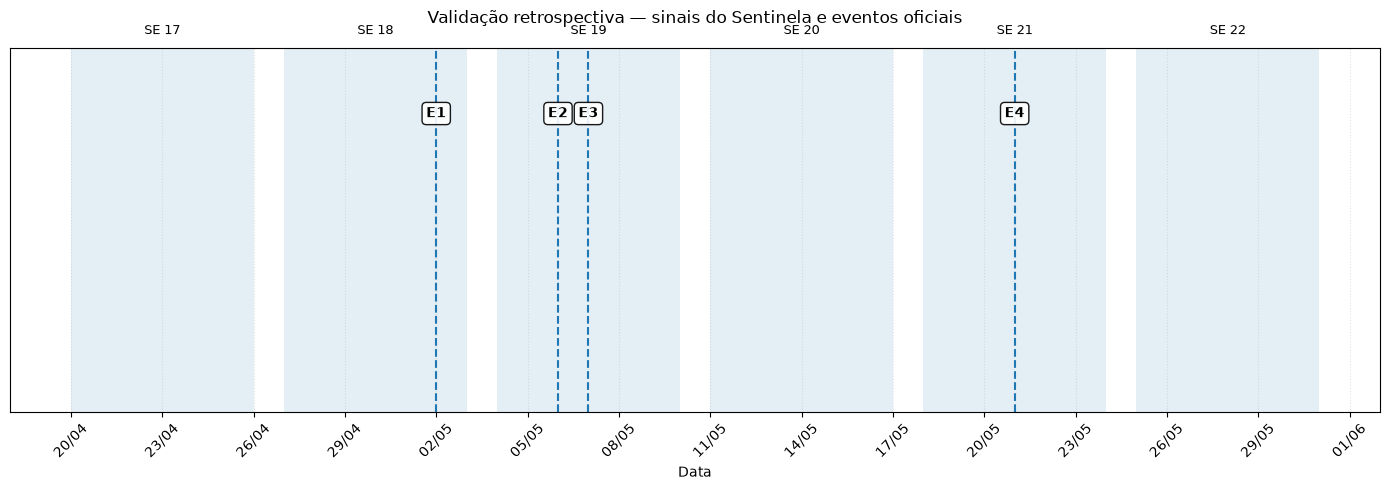

In [98]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

events_2025 = pd.DataFrame(
    [
        {
            "date": "2025-05-02",
            "label": "E1",
            "event": "MG decreta emergência em saúde pública por aumento de SRAG",
        },
        {
            "date": "2025-05-06",
            "label": "E2",
            "event": "Uberlândia decreta situação de emergência por SRAG",
        },
        {
            "date": "2025-05-07",
            "label": "E3",
            "event": "Primeira reunião do COE-Minas-SRAG",
        },
        {
            "date": "2025-05-21",
            "label": "E4",
            "event": "Uberlândia apresenta plano de enfrentamento das síndromes respiratórias",
        },
    ]
)

events_2025["date"] = pd.to_datetime(
    events_2025["date"]
)

fig, ax = plt.subplots(figsize=(14, 5))

for _, row in timeline_signals_2025.iterrows():
    ax.axvspan(
        row["week_start"],
        row["week_end"],
        alpha=0.12,
    )

    midpoint = (
        row["week_start"]
        + (row["week_end"] - row["week_start"]) / 2
    )

    ax.text(
        midpoint,
        1.03,
        f"SE {int(row['epi_week'])}",
        ha="center",
        va="bottom",
        transform=ax.get_xaxis_transform(),
        fontsize=9,
    )

for _, row in events_2025.iterrows():
    ax.axvline(
        row["date"],
        linestyle="--",
        linewidth=1.5,
    )

    ax.text(
        row["date"],
        0.82,
        row["label"],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "alpha": 0.9,
        },
    )

ax.set_xlim(
    pd.Timestamp("2025-04-18"),
    pd.Timestamp("2025-06-02"),
)

ax.set_ylim(0, 1)

ax.set_yticks([])

ax.xaxis.set_major_locator(
    mdates.DayLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d/%m")
)

ax.set_title(
    "Validação retrospectiva — sinais do Sentinela e eventos oficiais",
    pad=18,
)

ax.set_xlabel("Data")

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.35,
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

E1 — 02/05/2025: MG decreta emergência em saúde pública por aumento de SRAG
E2 — 06/05/2025: Uberlândia decreta situação de emergência por SRAG
E3 — 07/05/2025: Primeira reunião do COE-Minas-SRAG
E4 — 21/05/2025: Uberlândia apresenta plano de enfrentamento das síndromes respiratórias

### Interpretação

Os sinais identificados pelo Sentinela começaram na SE 17 e permaneceram até a SE 22 de 2025.

Durante esse mesmo intervalo, Minas Gerais e municípios do estado adotaram medidas oficiais de resposta ao aumento de SRAG, incluindo declaração de emergência, ativação de estruturas de coordenação e ampliação da capacidade assistencial.

A concordância temporal observada fortalece a hipótese de que o método utilizado pelo Sentinela consegue detectar alterações epidemiológicas relevantes.